# 02 — Chi-Square Test & Post-Hoc Analysis
**Eniac A/B Test | Nov 2 – Nov 16, 2021**

Now that we've explored the data, we need to determine whether the observed differences in CTR  
are **statistically significant** or could simply be the result of random variation.

**Hypotheses:**
- **H₀ (null):** All four versions have the same CTR. Any observed differences are due to chance.
- **H₁ (alternative):** At least one version has a statistically different CTR.

**Significance level:** α = 0.05 (95% confidence)


## 1. Imports & data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import chi2_contingency
from itertools import combinations

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

# Key figures extracted from the CSVs (see notebook 01 for extraction code)
data = {
    "Version_A": {"clicks": 512,  "visits": 25326},
    "Version_B": {"clicks": 281,  "visits": 24747},
    "Version_C": {"clicks": 527,  "visits": 24876},
    "Version_D": {"clicks": 193,  "visits": 25233},
}

results = pd.DataFrame(data).T.astype(int)
results["no_clicks"] = results["visits"] - results["clicks"]
results["ctr"]       = results["clicks"] / results["visits"]
results


,clicks,visits,no_clicks,ctr
Version_A,512,25326,24814,0.020216
Version_B,281,24747,24466,0.011355
Version_C,527,24876,24349,0.021185
Version_D,193,25233,25040,0.007649


## 2. Build the contingency table

A chi-square test requires a **contingency table** of observed counts.  
Rows = outcome (Click / No-click), Columns = version.


In [2]:
contingency = pd.DataFrame({
    version: [row["clicks"], row["no_clicks"]]
    for version, row in results.iterrows()
}, index=["Click", "No-click"])

print("Contingency table:")
contingency


Contingency table:


,Version_A,Version_B,Version_C,Version_D
Click,512.0,281.0,527.0,193.0
No-click,24814.0,24466.0,24349.0,25040.0


## 3. Chi-Square test — all four variants

In [3]:
alpha = 0.05

chi2, p_value, dof, expected = chi2_contingency(contingency)

print(f"Chi-square statistic : {chi2:.4f}")
print(f"Degrees of freedom   : {dof}")
print(f"p-value              : {p_value:.2e}")
print()

if p_value < alpha:
    print(f"✅  p-value ({p_value:.4f}) < α ({alpha}) → REJECT the null hypothesis.")
    print("   At least one version has a statistically different CTR.")
else:
    print(f"❌  p-value ({p_value:.4f}) ≥ α ({alpha}) → FAIL to reject the null hypothesis.")


Chi-square statistic : 224.0188
Degrees of freedom   : 3
p-value              : 2.72e-48

✅  p-value (0.0000) < α (0.05) → REJECT the null hypothesis.
   At least one version has a statistically different CTR.


## 4. Post-hoc pairwise tests (Bonferroni correction)

Rejecting H₀ tells us *something* is different, but not *which pair* differs significantly.  
We run a chi-square test for every pair of versions.

Because we make **6 pairwise comparisons**, we apply the **Bonferroni correction**:

```
adjusted α = 0.05 / 6 ≈ 0.0083
```

This controls the family-wise error rate and reduces the risk of false positives.


In [4]:
versions = list(results.index)
pairs    = list(combinations(versions, 2))
n_pairs  = len(pairs)
adj_alpha = alpha / n_pairs

print(f"Number of pairwise comparisons : {n_pairs}")
print(f"Bonferroni-adjusted α          : {adj_alpha:.6f}\n")

rows = []
for v1, v2 in pairs:
    sub = contingency[[v1, v2]]
    chi2_pair, p_pair, _, _ = chi2_contingency(sub)
    significant = p_pair < adj_alpha
    rows.append({
        "Pair": f"{v1} vs {v2}",
        "Chi²": round(chi2_pair, 4),
        "p-value": f"{p_pair:.2e}",
        "p < adj_α": "✅ Yes" if significant else "❌ No",
    })

pairwise_df = pd.DataFrame(rows).set_index("Pair")
pairwise_df


Number of pairwise comparisons : 6
Bonferroni-adjusted α          : 0.008333



,Chi²,p-value,p < adj_α
Pair,,,
Version_A vs Version_B,62.4936,2.67e-15,✅ Yes
Version_A vs Version_C,0.5342,4.65e-01,❌ No
Version_A vs Version_D,144.2832,3.08e-33,✅ Yes
Version_B vs Version_C,74.2292,6.96e-18,✅ Yes
Version_B vs Version_D,17.8763,2.36e-05,✅ Yes
Version_C vs Version_D,161.1170,6.45e-37,✅ Yes


## 5. Visualise pairwise p-values

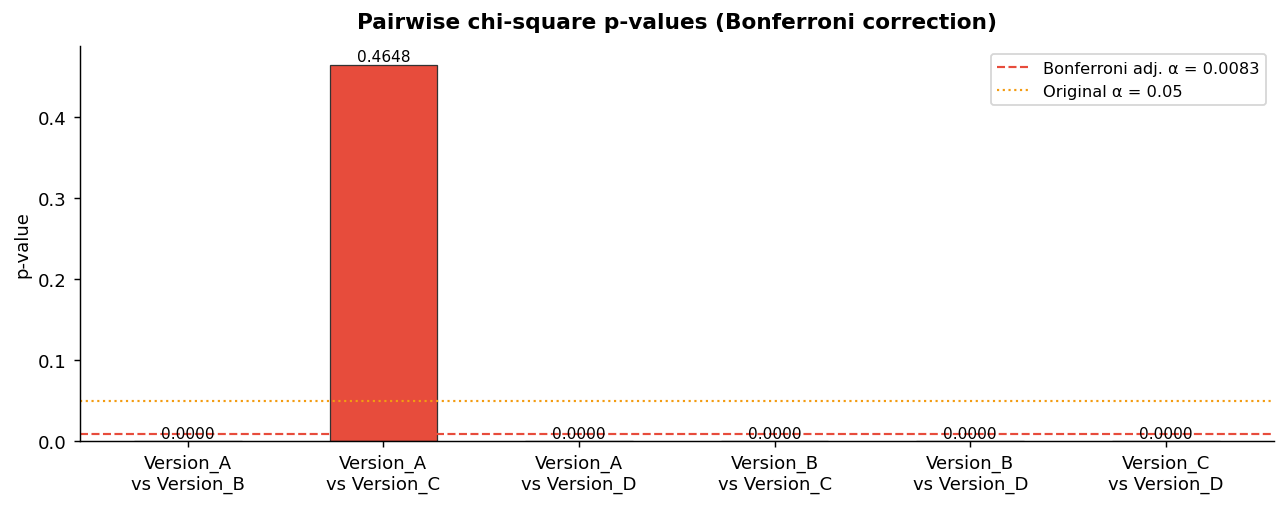

In [5]:
p_vals   = []
sig_list = []
labels   = []

for v1, v2 in pairs:
    sub = contingency[[v1, v2]]
    _, p_pair, _, _ = chi2_contingency(sub)
    p_vals.append(p_pair)
    sig_list.append(p_pair < adj_alpha)
    labels.append(f"{v1}\nvs {v2}")

colours = ["#2ecc71" if s else "#e74c3c" for s in sig_list]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(labels, p_vals, color=colours, edgecolor="#333", linewidth=0.7, width=0.55)
ax.axhline(adj_alpha, color="#e74c3c", linestyle="--", linewidth=1.2,
           label=f"Bonferroni adj. α = {adj_alpha:.4f}")
ax.axhline(alpha, color="#f39c12", linestyle=":", linewidth=1.2,
           label=f"Original α = {alpha}")
ax.set_title("Pairwise chi-square p-values (Bonferroni correction)", fontsize=12,
             fontweight="bold", pad=10)
ax.set_ylabel("p-value")
ax.legend(fontsize=9)

for bar, val in zip(bars, p_vals):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.0005,
            f"{val:.4f}", ha="center", va="bottom", fontsize=8.5)

plt.tight_layout()
plt.savefig("../images/pairwise_pvalues.png", bbox_inches="tight")
plt.show()


## 6. Secondary metrics

The pairwise tests show **A vs. C is not statistically significant** — they are too close to call  
on CTR alone. We therefore examine two secondary metrics to break the tie.

> **Note:** A data collection error made Version B's secondary metrics unavailable.

| Metric | Definition | Goal |
|--------|-----------|------|
| Drop-off rate | % of users who clicked the button but did not complete a purchase | Lower is better |
| Homepage-return rate | % of users who returned to the homepage after clicking | Lower is better |


In [6]:
# Secondary metrics (from tracked session data — Version B unavailable)
secondary = pd.DataFrame({
    "Version_A": {"drop_off_rate": 0.621, "homepage_return_rate": 0.054},
    "Version_C": {"drop_off_rate": 0.710, "homepage_return_rate": 0.047},
    "Version_D": {"drop_off_rate": 0.696, "homepage_return_rate": 0.026},
}).T

secondary["drop_off_rate_%"]       = secondary["drop_off_rate"] * 100
secondary["homepage_return_rate_%"] = secondary["homepage_return_rate"] * 100

secondary[["drop_off_rate_%", "homepage_return_rate_%"]]


,drop_off_rate_%,homepage_return_rate_%
Version_A,62.1,5.4
Version_C,71.0,4.7
Version_D,69.6,2.6


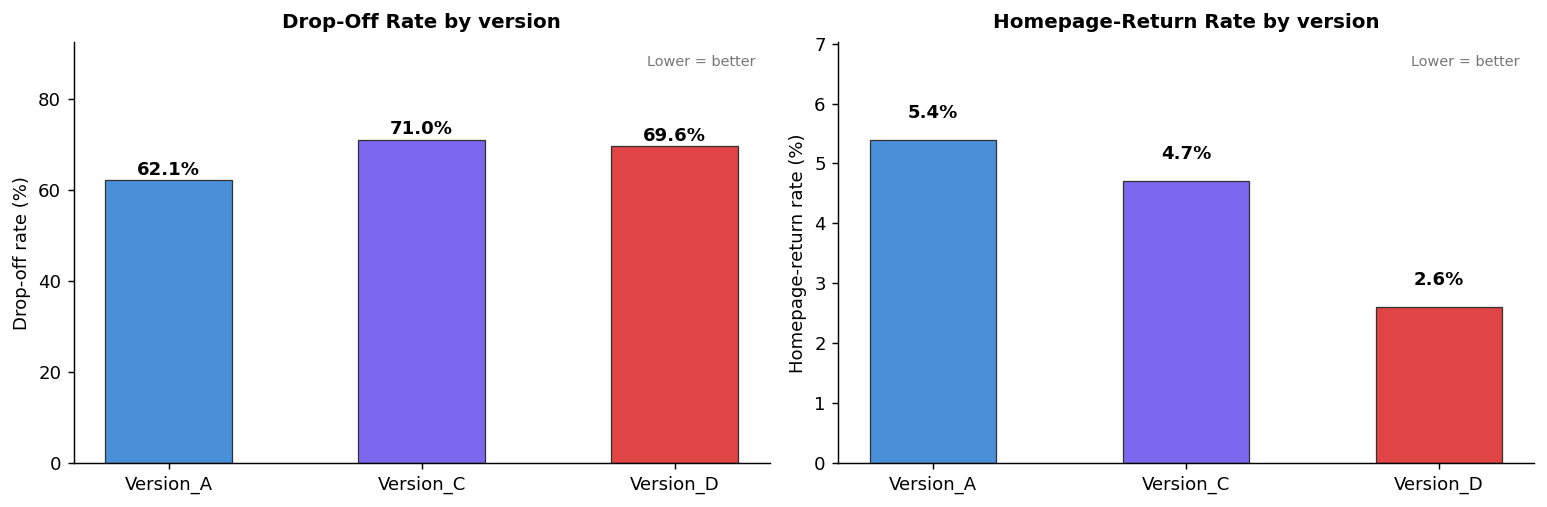

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
palette   = {"Version_A": "#4a90d9", "Version_C": "#7b68ee", "Version_D": "#e04444"}

for ax, col, title, ylabel in zip(
    axes,
    ["drop_off_rate_%", "homepage_return_rate_%"],
    ["Drop-Off Rate by version", "Homepage-Return Rate by version"],
    ["Drop-off rate (%)", "Homepage-return rate (%)"],
):
    vers   = secondary.index.tolist()
    vals   = secondary[col].tolist()
    cols   = [palette[v] for v in vers]
    bars   = ax.bar(vers, vals, color=cols, edgecolor="#333", linewidth=0.7, width=0.5)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, max(vals) * 1.3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
    ax.text(0.98, 0.97, "Lower = better", transform=ax.transAxes,
            ha="right", va="top", fontsize=8, color="#777")

plt.tight_layout()
plt.savefig("../images/secondary_metrics.png", bbox_inches="tight")
plt.show()


## 7. Final recommendation

### Summary of findings

| Version | CTR | Sig. different from A? | Drop-off rate | Homepage-return rate |
|---------|-----|----------------------|---------------|----------------------|
| **A** | 2.02% | — (control) | **62.1%** ✅ best | 5.4% |
| B | 1.14% | ✅ Yes (worse) | N/A | N/A |
| C | 2.12% | ❌ No | 71.0% | 4.7% |
| D | 0.76% | ✅ Yes (worse) | 69.6% | **2.6%** |

### Winner: **Version A — White "SHOP NOW"**

**Reasoning:**

1. **CTR** — Version C is marginally higher, but the difference is **not statistically significant**.  
   We cannot confidently claim C is better than A on this metric.

2. **Drop-off rate** — Version A has a substantially lower drop-off rate (62.1% vs 71.0%).  
   Users who click "SHOP NOW" are more likely to continue through the purchase funnel.

3. **Conclusion** — Switching to red (versions B or D) would be actively harmful.  
   Replacing "SHOP NOW" with "SEE DEALS" (version C) does not improve CTR significantly  
   and leads to worse post-click behaviour.

**Recommendation: keep the original white "SHOP NOW" button.**  
If further optimisation is desired, a follow-up experiment could test more radical redesigns  
(e.g. button size, placement, or surrounding copy) with a revised MDE.
